---
title: Linear Regression for Time Series
---

The first topic in the class would be linear regression. We will see some simple examples of this today. Just plain linear regression usually does not work well for time series analysis; so we will see more sophisticated models later on in the course. 

In [27]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

## US Population Dataset

This dataset is downloaded from FRED and gives monthly population of the United States in thousands. 

In [28]:
uspop = pd.read_csv('POPTHM_27Aug2026.csv')
print(uspop.head(10))
print(uspop.tail(10))

  observation_date  POPTHM
0       1959-01-01  175818
1       1959-02-01  176044
2       1959-03-01  176274
3       1959-04-01  176503
4       1959-05-01  176723
5       1959-06-01  176954
6       1959-07-01  177208
7       1959-08-01  177479
8       1959-09-01  177755
9       1959-10-01  178026
    observation_date  POPTHM
801       2025-10-01  342366
802       2025-11-01  342439
803       2025-12-01  342495
804       2026-01-01  342540
805       2026-02-01  342581
806       2026-03-01  342627
807       2026-04-01  342680
808       2026-05-01  342746
809       2026-06-01  342822
810       2026-07-01  342909


Here is a plot of the dataset. 

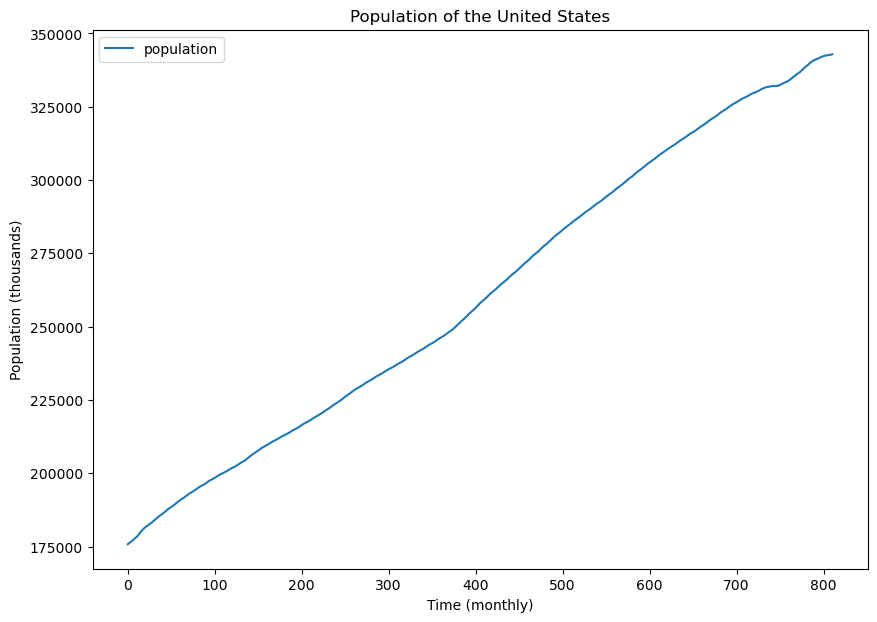

In [29]:
plt.figure(figsize=(10, 7))
plt.plot(uspop['POPTHM'], label = "population")
plt.xlabel("Time (monthly)")
plt.ylabel("Population (thousands)")
plt.title("Population of the United States")
plt.legend()
plt.show()

For each time $i$ (here time refers to a specific month in the dataset; $i = 1$ is January 1959, $i = 2$ is February 1959 and so on), let $y_i$ denote the observed US population (in thousands) for time $i$. 

Consider the problem of predicting the US population in a future month, say July 2040. Here is one simple way of doing this. We use the linear regression model: 
\begin{align*}
   y_i = \beta_0 + \beta_1 i + \text{error} ~~~ \text{ for all $i$}. 
\end{align*}
We will fit this model to the data, which means $\beta_0$ and $\beta_1$ will be selected so that $\sum_{i=1}^n (y_i - \beta_0 - \beta_1 i)^2$ is minimized. If the resulting values of $\beta_0$ and $\beta_1$ are denoted by $\hat{\beta}_0$ and $\hat{\beta}_1$, then the prediction for any future time $T$ is given by $\hat{\beta}_0 + \hat{\beta}_1 T$.  These values $\hat{\beta}_0$ and $\hat{\beta}_1$ have the following explicit formula. Let $x_i = i$ so that the least squares estimators $\hat{\beta}_0$ and $\hat{\beta}_1$ minimize $$S(\beta_0, \beta_1) := \sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i)^2$$ over all values of $\beta_0$ and $\beta_1$. Then
\begin{equation*}
   \hat{\beta}_1 = \frac{\sum_{i=1}^n (y_i - \bar{y})(x_i - \bar{x})}{\sum_{i=1}^n (x_i - \bar{x})^2} \text{ and } \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}. 
\end{equation*}
Here is the proof of this formula. We need to take the derivative of $S(\beta_0, \beta_1)$ with respect to $\beta_0$ and $\beta_1$ and equate them to zero. This gives: 
\begin{align*}
   &\frac{\partial}{\partial \beta_0} S(\beta_0, \beta_1) = 0 \implies \sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i) = 0 \\
   &\frac{\partial}{\partial \beta_1} S(\beta_0, \beta_1) = 0 \implies \sum_{i=1}^n x_i(y_i - \beta_0 - \beta_1 x_i) = 0 
\end{align*}
Clearly the first equation is the same as: 
\begin{equation*}
   \beta_0 = \bar{y} - \beta_1 \bar{x}. 
\end{equation*}
Plugging this value of $\beta_0$ in the second equation, we get
\begin{equation*}
    0 = \sum_{i=1}^n x_i (y_i - \bar{y} - \beta_1 (x_i - \bar{x})) \implies \beta_1 = \frac{\sum_{i=1}^n x_i (y_i - \bar{y})}{\sum_{i=1}^n x_i (x_i - \bar{x})} = \frac{\sum_{i=1}^n (y_i - \bar{y})(x_i - \bar{x})}{\sum_{i=1}^n (x_i - \bar{x})^2}. 
\end{equation*}
There is a slightly different way of solving the equations. Use the vector matrix notation: 
\begin{align*}
   y = \begin{pmatrix} y_1 \\ y_2 \\ \cdot \\ \cdot \\ \cdot \\ y_n \end{pmatrix} ~~ X = \begin{pmatrix}1 & x_1 \\ 1 & x_2 \\ \cdot & \cdot \\ \cdot & \cdot \\ \cdot & \cdot \\ 1 & x_n \end{pmatrix} ~~ \beta = \begin{pmatrix}\beta_0 \\ \beta_1 \end{pmatrix}. 
\end{align*}
The two equations corresponding to $\frac{\partial}{\partial \beta_0} S(\beta_0, \beta_1) = 0$ and $\frac{\partial}{\partial \beta_1} S(\beta_0, \beta_1) = 0$ can be written using this notation as: 
\begin{align*}
  X^T (y - X \beta) = 0 \implies X^T X \beta = X^T y \implies \beta = (X^T X)^{-1} X^T y. 
\end{align*}
Writing out $(X^T X)^{-1}$ and multiplying out the product above, we can deduce the formulae for $\hat{\beta}_0$ and $\hat{\beta}_1$.





For the us population data where $y_i$ is the population at time $i$ and $x_i = i$, we compute $\hat{\beta}_0$ and $\hat{\beta}_1$ as follows. 

In [30]:
y = uspop['POPTHM']
x = 1 + np.arange(len(y))
b1hat = (np.sum((x - np.mean(x)) * (y - np.mean(y)))) / (np.sum((x - np.mean(x))**2))
b0hat = np.mean(y) - b1hat * np.mean(x)
print(b0hat, b1hat)

174585.548486094 213.2157349309609


The estimate of $\hat{\beta}_0$ is approximately $174585$ (note that if we ignore the error term then $y_0 = \beta_0$ i.e., $y_i = \beta_0 + \beta_1 i$ for $i = 0$ gives $y_0 = \beta_0$). This means that, at time 0 (i.e., for December 1958), the population estimate is 174.585 million. The estimate of $\hat{\beta}_1$ is 213.215. This means, that for every additional month, US population increases by about $213$ thousand people. Equivalently, for every additional year the population increases by about $12 \times 213.2$ or about 2.56 million people per year. 

Below we plot the fitted line $\hat{\beta}_0 + \hat{\beta}_1 x$ on the observed data. 

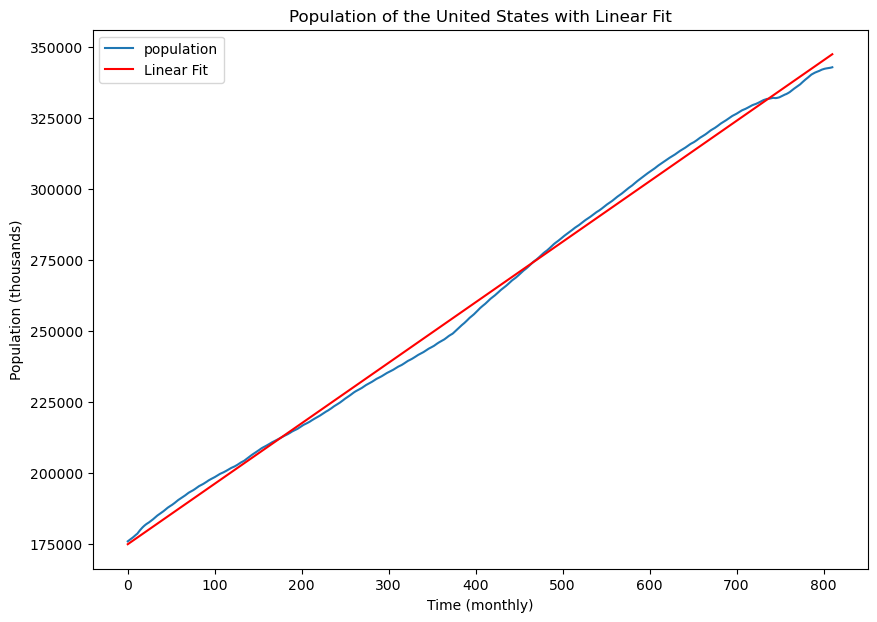

In [31]:
plt.figure(figsize=(10, 7))
plt.plot(uspop['POPTHM'], label = "population")
plt.plot(b0hat + b1hat * x, color='red', label = 'Linear Fit')
plt.xlabel("Time (monthly)")
plt.ylabel("Population (thousands)")
plt.title("Population of the United States with Linear Fit")
plt.legend()
plt.show()


Using this fitted line, we can predict the population for July 2040 as follows. Since time index $n$ corresponds to July 2026 and July 2040 is 168 months after July 2026, we need to evaluate $\hat{\beta}_0 + \hat{\beta}_1 i$ for $i = n + 168$.

In [32]:
n = len(y)
i = n+168
predicted_population_july_2040 = b0hat + b1hat * i
print(predicted_population_july_2040)

383323.75298350473


Since our units are in thousands, the predicted population for July 2040 it about 383 million. 

The census bureau releases projections of future populations (see this website: \url{https://www.census.gov/data/tables/2023/demo/popproj/2023-summary-tables.html}; download Table 1 from there). In this website, the projected population for July 2040 is 355 million. So our prediction is somewhat larger than the projection from the Census Bureau. 

Instead of calculating $\hat{\beta}_0$ and $\hat{\beta}_1$ manually as above, we can use the inbuilt OLS function from the library statsmodels in python (OLS stands for Ordinary Least Squares). This requires specifying the vector $y$ of $y_1, \dots, y_n$ as well as the matrix $X$ described above. 
\begin{align*}
   y = \begin{pmatrix} y_1 \\ y_2 \\ \cdot \\ \cdot \\ \cdot \\ y_n \end{pmatrix} ~~ X = \begin{pmatrix}1 & x_1 \\ 1 & x_2 \\ \cdot & \cdot \\ \cdot & \cdot \\ \cdot & \cdot \\ 1 & x_n \end{pmatrix}. 
\end{align*}


In [33]:
y = uspop['POPTHM']
n = len(y)
x = np.arange(1, n + 1)
X = np.column_stack([np.ones(n),x]) #this is the X matrix above

md = sm.OLS(y, X).fit()
print(md.summary())


                            OLS Regression Results                            
Dep. Variable:                 POPTHM   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 2.794e+05
Date:                Fri, 28 Aug 2026   Prob (F-statistic):               0.00
Time:                        23:01:06   Log-Likelihood:                -7554.3
No. Observations:                 811   AIC:                         1.511e+04
Df Residuals:                     809   BIC:                         1.512e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.746e+05    189.054    923.472      0.0

The coefficients appearing in the above table refer to $\hat{\beta}_0$ and $\hat{\beta}_1$: the coefficient corresponding to 'const' is $\hat{\beta}_0$ and the coefficient corresponding $\hat{\beta}_1$. 

In [34]:
#Below we check if our manual calculations of b0hat and b1hat match the results from statsmodels: 
print(b0hat, b1hat)
print(md.params) #params stands for parameters, which are the coefficients of the linear regression model. The first value corresponds to b0hat (intercept) and the second value corresponds to b1hat (slope).

174585.548486094 213.2157349309609
const    174585.548486
x1          213.215735
dtype: float64


For predicting the population at the future time point July 2040, we can also use the inbuilt predict function from statsmodels. 

In [36]:
#predicting population in July 2040 using the statsmodels results
#we use the predict function
n = len(y)
i = n+168
predicted_population_july_2040_statsmodels = md.predict([1, i])
print(predicted_population_july_2040_statsmodels)
print(predicted_population_july_2040) #this is the predicted population using our manual calculations

[383323.7529835]
383323.75298350473


The predict function also gives an uncertainty for the prediction. We shall see how to derive this uncertainty interval later in the course.

In [37]:
#prediction interval for July 2040 using the statsmodels results
#we use the get_prediction function
prediction = md.get_prediction([1, i])
prediction_summary = prediction.summary_frame(alpha=0.05) #alpha is the significance level,
#which is 0.05 for a 95% prediction interval
print(prediction_summary)
#the obs_ci_lower and obs_ci_upper columns give the lower and upper bounds of the prediction interval, respectively
print("Prediction interval for July 2040: [{}, {}]".format(prediction_summary['obs_ci_lower'][0], prediction_summary['obs_ci_upper'][0]))

            mean     mean_se  mean_ci_lower  mean_ci_upper   obs_ci_lower  \
0  383323.752984  249.690077  382833.636169  383813.869798  378021.927813   

    obs_ci_upper  
0  388625.578154  
Prediction interval for July 2040: [378021.92781324557, 388625.57815376366]


So the prediction for the population in July 2040 is between 378 million and 388.6 million. The census bureau prediction is much smaller however. 

## Fitting a Quadratic Trend

Suppose we now use the model: 
\begin{align*}
  y_i = \beta_0 + \beta_1 i + \beta_2 i^2 + \text{error}
\end{align*}
In this case, the $X$ matrix becomes: 
\begin{align*}
   y = \begin{pmatrix} y_1 \\ y_2 \\ \cdot \\ \cdot \\ \cdot \\ y_n \end{pmatrix} ~~ X = \begin{pmatrix}1 & x_1 & x_1^2\\ 1 & x_2 & x_2^2 \\ \cdot & \cdot & \cdot \\ \cdot & \cdot & \cdot \\ \cdot & \cdot & \cdot \\ 1 & x_n & x_n^2 \end{pmatrix}. 
\end{align*}
where, as before, $x_i = i^2$. With this specification of $X$, the statsmodels code works in the same way as before. 

In [16]:
y = uspop['POPTHM']
n = len(y)
x = np.arange(1, n + 1)
X = np.column_stack([np.ones(n),x, x ** 2]) #this is the X matrix above

md2 = sm.OLS(y, X).fit()
print(md2.summary())
 

                            OLS Regression Results                            
Dep. Variable:                 POPTHM   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 1.569e+05
Date:                Fri, 28 Aug 2026   Prob (F-statistic):               0.00
Time:                        21:36:26   Log-Likelihood:                -7506.9
No. Observations:                 811   AIC:                         1.502e+04
Df Residuals:                     808   BIC:                         1.503e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.766e+05    268.068    658.741      0.0

Below we plot the observed data with the fitted quadratic (this is obtained using the "fittedvalues" attribute below). 

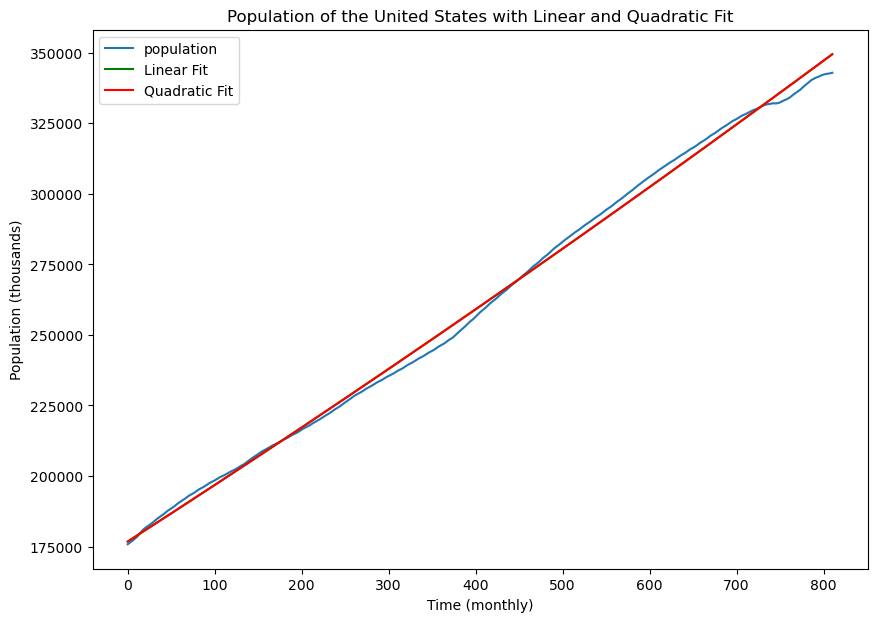

In [19]:
plt.figure(figsize=(10, 7))
plt.plot(uspop['POPTHM'], label = "population")
plt.plot(md.fittedvalues, color='green', label = 'Linear Fit')
plt.plot(md2.fittedvalues, color='red', label = 'Quadratic Fit')
plt.xlabel("Time (monthly)")
plt.ylabel("Population (thousands)")
plt.title("Population of the United States with Linear and Quadratic Fit")
plt.legend()
plt.show()

There is not much difference between the linear and quadratic fits. Note that fitted value of $\beta_2$ above is positive (0.0182). This means that the quadratic is trending upward (convex) which means that it will give an even larger prediction for July 2040 compared to the linear regression model. 

In [38]:
#predicting the population in July 2040 using the statsmodels results
n = len(y)
i = n+168
predicted_population_july_2040_quadratic = md2.predict([1, i, i**2])
print(predicted_population_july_2040_quadratic)

[388300.29946012]


The predicted population (July 2040) by the quadratic model is 388.3 million which is more than the prediction given by the linear trend model. 

## Modeling Logarithms:

Another variant of these models is to use the model for the logarithm of the data, than the original data. 

In [39]:
ylog = np.log(uspop['POPTHM'])
n = len(ylog)
x = np.arange(1, n + 1)
X = np.column_stack([np.ones(n),x]) #this is the X matrix

mdlog = sm.OLS(ylog, X).fit()
print(mdlog.summary())

                            OLS Regression Results                            
Dep. Variable:                 POPTHM   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 1.370e+05
Date:                Fri, 28 Aug 2026   Prob (F-statistic):               0.00
Time:                        23:04:02   Log-Likelihood:                 2257.3
No. Observations:                 811   AIC:                            -4511.
Df Residuals:                     809   BIC:                            -4501.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.1164      0.001   1.15e+04      0.0

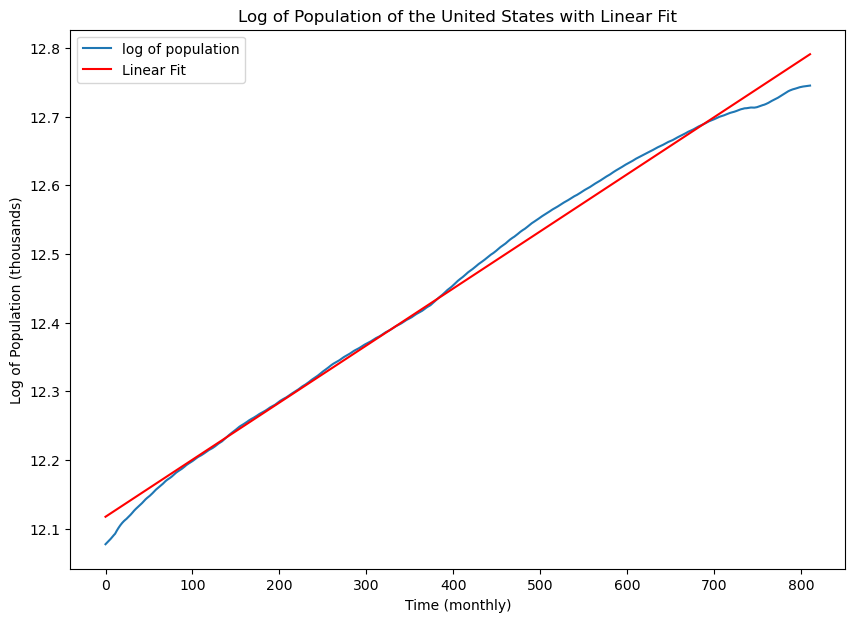

In [26]:
#Plotting the log of the population and the linear fit
plt.figure(figsize=(10, 7))
plt.plot(ylog, label = "log of population")
plt.plot(mdlog.fittedvalues, color='red', label = 'Linear Fit')
plt.xlabel("Time (monthly)")
plt.ylabel("Log of Population (thousands)")
plt.title("Log of Population of the United States with Linear Fit")
plt.legend()
plt.show()

From the plot above, the fitted line closely tracks the data, but in recent times, the actual log population is much lower than the fitted line. It is then clear that a prediction based on the line would be quite large. 

Below we predict the population in July 2040 using this model. This model will provide a prediction for $\log y_t$ which needs to be exponentiated to get prediction for $y_t$. 

In [25]:
#predicting the population in July 2040 using the statsmodels results
n = len(ylog)
i = n+168
predicted_population_july_2040_log = mdlog.predict([1, i])
print(np.exp(predicted_population_july_2040_log)) #we take the exponential of the predicted value to get the predicted population in thousands

[412762.30604638]


The prediction now is 412.7 million which is even larger than the previously obtain prediction for the linear model directly fitted to $y_t$. 

How to do improved modeling which gives more realistic future predictions (perhaps closer to the population projections by the Census Bureau)? We shall see some answers later in the course. 